# 01 零样本图像分类（CLIP评测
）

**目标**：不训练任何参数，直接用预训练 CLIP 对图像做分类。做法是把「类别名」当作文本 prompt，与图像一起输入 CLIP，用相似度最高的类别作为预测结果。

**步骤概览**：
1. 安装依赖并加载 CLIP 模型、处理器、分词器
2. 加载 CIFAR10（10 类）
3. 单张图像分类演示：理解 `logits_per_image` 与 softmax
4. 对测试集默认 1000 张图像批量分类
5. 计算准确率、精确率、召回、F1，并**可视化混淆矩阵**

## 1. 安装依赖

若已安装可跳过。需要：`transformers`（CLIP）、`torch`、`datasets`（CIFAR10）、`matplotlib`、`scikit-learn`（指标与混淆矩阵）。

## 2. 加载主干项目训练好的模型（best.pt）
使用本仓库训练得到的 CLIP 模型（ViT 图像编码 + CLIP 文本编码 + 256 维投影），权重为项目根目录下的 `best.pt`；tokenizer 与图像预处理与训练时一致。

In [1]:
# 导入依赖并挂载主干项目
import sys
from pathlib import Path
import numpy as np
import torch
from PIL import Image
from transformers import CLIPTokenizer
from datasets import load_dataset, load_from_disk
from tqdm import tqdm

# 项目根目录（自动检测，notebook 在 notebooks/baseCLIP_project 下）
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "config.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import config as CFG
from dataset import get_transforms
from models import CLIPModel as ProjectCLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = CLIPTokenizer.from_pretrained(CFG.clip_local_dir or CFG.text_tokenizer)
transforms = get_transforms(mode="valid")
model = ProjectCLIPModel().to(device)
model.load_state_dict(torch.load(ROOT / "best.pt", map_location=device))
model.eval()

def pil_to_tensor(pil_img):
    """PIL 转项目内图像 tensor (1, C, H, W)。"""
    img_np = np.array(pil_img)
    if len(img_np.shape) == 2:
        img_np = np.stack([img_np] * 3, axis=-1)
    out = transforms(image=img_np)["image"]
    return torch.tensor(out).permute(2, 0, 1).float().unsqueeze(0)

def classify(image, labels):
    """零样本分类：用主干项目模型，图像与各类别文本相似度取最大为预测。"""
    image_t = pil_to_tensor(image).to(device)
    enc = tokenizer(labels, padding=True, truncation=True, max_length=CFG.max_length, return_tensors="pt")
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        image_emb = model.image_projection(model.image_encoder(image_t))
        image_emb = torch.nn.functional.normalize(image_emb, p=2, dim=-1)
        text_emb = model.text_projection(model.text_encoder(input_ids=input_ids, attention_mask=attention_mask))
        text_emb = torch.nn.functional.normalize(text_emb, p=2, dim=-1)
        logits = (text_emb @ image_emb.T).squeeze(1) / model.temperature
    probs = logits.softmax(dim=0)
    return probs.argmax().item(), probs.unsqueeze(0)

/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 198/198 [00:00<00:00, 737.13it/s, Materializing param=layernorm.weight]                                 
ViTModel LOAD REPORT from: /root/CLIP_26_ylslch/checkpoint/google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 196/196 [00:0

## 3. 加载 CIFAR10 数据集
CIFAR10 共 10 类（飞机、汽车、鸟、猫、鹿、狗、蛙、马、船、卡车），零样本时用这 10 个英文类名作为文本 prompt。

In [2]:
# 加载 CIFAR10 数据集（使用本地 dataset/cifar10，避免在线下载）
dataset = load_from_disk(str(ROOT / "dataset" / "cifar10"))

# 显示标签列表
labels = dataset["train"].features["label"].names
print(labels)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 4. 单张图像分类：理解流程
classify(image, labels) 将图像与所有类别名送入 CLIP，得到 logits_per_image（图像与各文本的相似度），softmax 后 argmax 即预测类别。

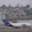

预测类别: airplane
各类别概率: {'airplane': 0.425483375787735, 'automobile': 0.05045755207538605, 'bird': 0.020136406645178795, 'cat': 0.016080517321825027, 'deer': 0.011767303571105003, 'dog': 0.01788868010044098, 'frog': 0.010633706115186214, 'horse': 0.019962335005402565, 'ship': 0.3168147802352905, 'truck': 0.11077535152435303}


In [3]:
# 取训练集第一张图做演示（classify 已在上面「加载模型」cell 中定义，使用主干模型）
image = dataset["train"][0]["img"]
pred_idx, probs = classify(image, labels)
display(image)
print(f"预测类别: {labels[pred_idx]}")
print(f"各类别概率: {dict(zip(labels, probs[0].tolist()))}")

## 5. 对测试集图像（默认 1000 张）进行分类
接下来对 CIFAR 测试集使用相同方法。创建变量 "predictions" 存储每张图像的预测标签。为计算后续指标，同时保存真实标签。
第一步：遍历数据集，对每张图像分类并保存预测标签。

In [4]:
predictions= [] 
eval_size = min(1000, len(dataset['test']))
eval_dataset = dataset['test'].select(range(eval_size))
ground_truth= [d['label'] for d in eval_dataset]

for img in tqdm(eval_dataset):
    pred_idx, _ = classify(img['img'], labels)
    predictions.append(pred_idx)

100%|██████████| 1000/1000 [00:10<00:00, 91.70it/s]


为评估分类性能，使用 sklearn 模块中的函数计算一组指标。
我们将重点查看准确率、精确率、召回率和 F1；并计算混淆矩阵以了解哪些类别被误分类。

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
y_true = ground_truth 
y_pred = predictions 

# 计算准确率
accuracy = accuracy_score(y_true, y_pred)
print(f'准确率: {accuracy:.4f}')

precision = precision_score(y_true, y_pred, average='weighted')
print(f'精确率: {precision:.4f}')

recall = recall_score(y_true, y_pred, average='weighted')
print(f'召回率: {recall:.4f}')

f1 = f1_score(y_true, y_pred, average='weighted')
print(f'F1 分数: {f1:.4f}')

# 生成分类报告
print('\n分类报告:')
print(classification_report(y_true, y_pred))

# 生成混淆矩阵
conf_matrix = confusion_matrix(y_true, y_pred)
print('\n混淆矩阵:')
print(conf_matrix)

/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

准确率: 0.5200
精确率: 0.4682
召回率: 0.5200
F1 分数: 0.4777

分类报告:
              precision    recall  f1-score   support

           0       0.50      0.51      0.50       103
           1       0.04      0.03      0.04        89
           2       0.55      0.42      0.47       100
           3       0.00      0.00      0.00       103
           4       0.56      0.32      0.41        90
           5       0.67      0.62      0.64        86
           6       0.51      0.48      0.50       112
           7       0.83      0.88      0.85       102
           8       0.58      0.92      0.72       106
           9       0.44      0.90      0.59       109

    accuracy                           0.52      1000
   macro avg       0.47      0.51      0.47      1000
weighted avg       0.47      0.52      0.48      1000


混淆矩阵:
[[53  4  4  0  1  0  0  0 41  0]
 [ 2  3  0  0  0  0  0  0 11 73]
 [ 5  4 42  0 14  2 28  1  3  1]
 [15 10 17  0  2 16 20  4  3 16]
 [12  3  4  0 29  1  2 12  1 26]
 [12  7  3  

## 混淆矩阵可视化
下图横轴为预测类别，纵轴为真实类别；对角线为正确分类数量，非对角线为混淆情况（如蛙被误分为鸟、猫被误分为狗等）。

/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/2043537275.py:7: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missi

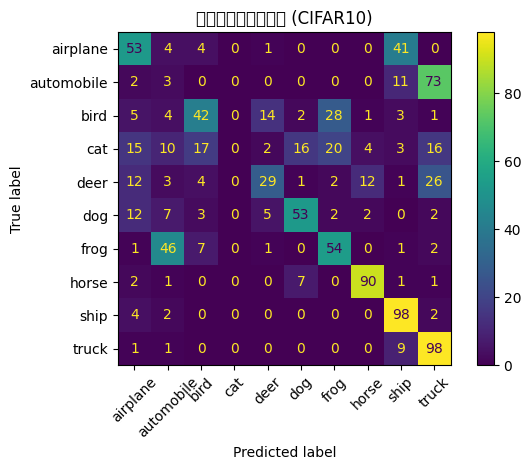

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(xticks_rotation=45, values_format='d')
plt.title('零样本分类混淆矩阵 (CIFAR10)')
plt.tight_layout()
plt.show()

## 6. 分析
CLIP 取得了约 87.3% 的准确率。
混淆矩阵显示青蛙和猫的召回率较低。青蛙常被误分为鸟，猫常被误分为狗。
下一节将介绍提示工程，探讨提升分数的可能方法。


[CLIP 论文](https://arxiv.org/pdf/2103.00020.pdf) 指出，训练集中很少用单个词描述图像。因此在标签前添加「a photo of」在 ImageNet 上使准确率提升 1.3%。
下面我们尝试该做法并观察是否有提升。

In [7]:
# 定义新标签（加 a photo of 前缀）
new_labels = [f"a photo of {label}" for label in labels]
print(new_labels)

['a photo of airplane', 'a photo of automobile', 'a photo of bird', 'a photo of cat', 'a photo of deer', 'a photo of dog', 'a photo of frog', 'a photo of horse', 'a photo of ship', 'a photo of truck']


复用上面的代码，重新运行得到：

In [8]:
predictions= [] 
eval_size = min(1000, len(dataset['test']))
eval_dataset = dataset['test'].select(range(eval_size))
ground_truth= [d['label'] for d in eval_dataset]

for img in tqdm(eval_dataset):
    pred_idx, _ = classify(img['img'], new_labels)
    predictions.append(pred_idx)

100%|██████████| 1000/1000 [00:11<00:00, 87.47it/s]


/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1729/4027715047.py:30: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}

准确率: 0.5400
精确率: 0.5083
召回率: 0.5400
F1 分数: 0.4884

分类报告:
              precision    recall  f1-score   support

           0       0.39      0.86      0.53       103
           1       0.05      0.06      0.05        89
           2       0.58      0.37      0.45       100
           3       0.00      0.00      0.00       103
           4       0.72      0.14      0.24        90
           5       0.65      0.88      0.75        86
           6       0.57      0.39      0.47       112
           7       0.82      0.92      0.87       102
           8       0.65      0.89      0.75       106
           9       0.63      0.81      0.71       109

    accuracy                           0.54      1000
   macro avg       0.51      0.53      0.48      1000
weighted avg       0.51      0.54      0.49      1000


混淆矩阵:
[[89  0  2  0  0  0  0  0 12  0]
 [30  5  0  0  0  0  0  0 16 38]
 [20  8 37  0  4  3 23  2  3  0]
 [24 15 13  0  0 31  7  2  2  9]
 [33  9  9  0 13  3  3 15  2  3]
 [ 5  2  1  

/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38646 (\N{CJK UNIFIED IDEOGRAPH-96F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/miniconda3/envs/ylslch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: G

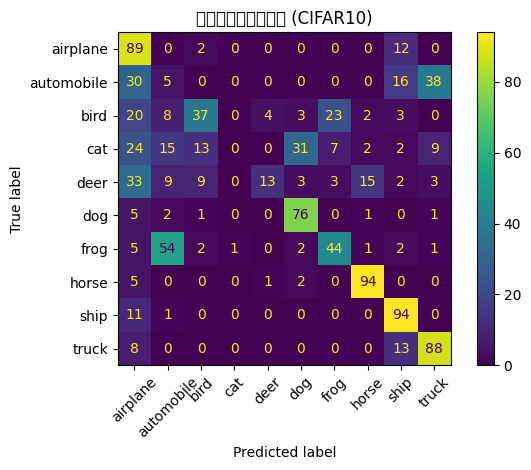

In [9]:
y_true = ground_truth 
y_pred = predictions 

# 计算准确率
accuracy = accuracy_score(y_true, y_pred)
print(f'准确率: {accuracy:.4f}')

precision = precision_score(y_true, y_pred, average='weighted')
print(f'精确率: {precision:.4f}')

recall = recall_score(y_true, y_pred, average='weighted')
print(f'召回率: {recall:.4f}')

f1 = f1_score(y_true, y_pred, average='weighted')
print(f'F1 分数: {f1:.4f}')

# 生成分类报告
print('\n分类报告:')
print(classification_report(y_true, y_pred))

# 生成混淆矩阵
conf_matrix = confusion_matrix(y_true, y_pred)
print('\n混淆矩阵:')
print(conf_matrix)

# 图中仅显示原类别名（不显示 new_label）以便阅读
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(xticks_rotation=45, values_format='d')
plt.title('零样本分类混淆矩阵 (CIFAR10)')
plt.tight_layout()
plt.show()